In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt


class HeatSimulation:
    def __init__(self, N):
        self.N = N
        self.metal_temp = np.zeros(N)
        

    def iterate(self):
        self.metal_temp[0] = 100
        self.metal_temp[-1] = 0
        new_temp = self.metal_temp.copy()

        for i in range(1, self.N - 1):
            new_temp[i] = (self.metal_temp[i - 1] + self.metal_temp[i + 1]) / 2
        self.metal_temp = new_temp

    def simulate(self, total_steps):
        steps = 0
        for j in range(1, self.N - 1):
             self.metal_temp[j] = 50
        while steps <= total_steps:
            self.iterate()
            steps += 1

    def plot_temperature(self):
        plt.plot(self.metal_temp)
        plt.xlabel('Position along the rod')
        plt.ylabel('Temperature (°C)')
        plt.title('Temperature Distribution along the Metal Rod')
        plt.grid()
        plt.show()


N = int(input("Enter the number of segments in the metal rod: "))
total_steps = int(input("Enter the number of time steps to simulate: "))
simulation = HeatSimulation(N)
simulation.simulate(total_steps)
simulation.plot_temperature()

        



第 54 题：用 NumPy 矩阵解热传导

题目描述：
不再使用循环迭代，我们要利用线性代数库直接求出“最终答案”（稳态分布）。

任务要求：
定义类 MatrixHeatSolver：

初始化 __init__(self, N)

N 为总点数（包含边界）。

内部构建一个 (N−2)×(N−2) 的系数矩阵 A。

对角线元素全为 2。

对角线两侧紧邻的元素全为 -1。

构建一个长度为 N−2 的向量 b。

第一个元素是左边界值（100）。

最后一个元素是右边界值（0）。

中间元素为 0。

方法 solve(self)

使用 np.linalg.solve(A, b) 直接解出中间点的温度。

将结果拼接上两端的边界值 [100, ..., 0]。

方法 plot_result(self)

绘图。

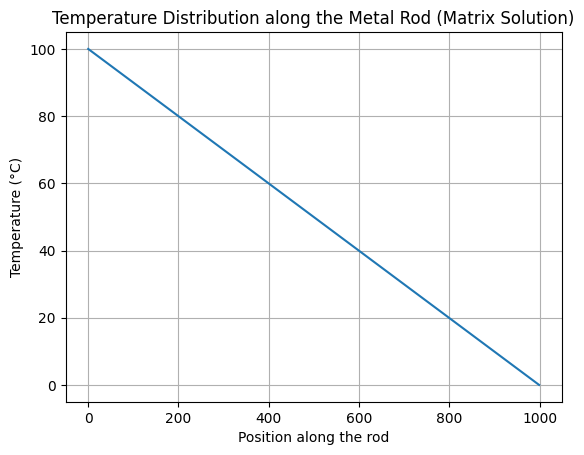

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

class MatrixHeatSolver:
    def __init__(self, N):
        self.N = N
        self.metal_temp = np.zeros(N)
        main_diag = -2 * np.ones(N-2)
        off_diag = np.ones(N-3)
        self.matrixA = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
        self.vectorB = np.zeros(N-2)
        self.vectorB[0] = -100
        self.vectorB[-1] = 0
    def solve(self):
        self.metal_temp[0] = 100
        self.metal_temp[-1] = 0
        self.metal_temp[1:-1] = np.linalg.solve(self.matrixA, self.vectorB)
    def plot_temperature(self):
        plt.plot(self.metal_temp)
        plt.xlabel('Position along the rod')
        plt.ylabel('Temperature (°C)')
        plt.title('Temperature Distribution along the Metal Rod (Matrix Solution)')
        plt.grid()
        plt.show()

N = int(input("Enter the number of segments in the metal rod: "))
matrix_solver = MatrixHeatSolver(N)
matrix_solver.solve()
matrix_solver.plot_temperature()



第 55 题：离散二阶微分算符

在量子力学中，动能项通常涉及二阶导数 dx2d2​。在离散空间中，这个算符可以用你刚才构建的那个矩阵 A 来近似。

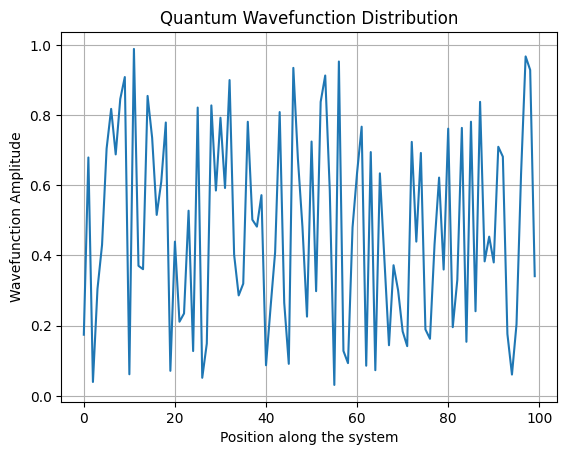

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt



def set_matrix_subdiagonal(matrix, value):
    for i in range(1, len(matrix) - 1):
        matrix[i][i-1] = value
        matrix[i][i+1] = value

class QuantumOperator:
    def __init__(self, N):
        self.N = N
        self.matrix = np.zeros((N, N))
        set_matrix_subdiagonal(self.matrix, 1)
        np.fill_diagonal(self.matrix, -2)

    def apply(self, psi):
        return np.dot(self.matrix, psi)
    
    def generate_wave(self, mode):
        if mode == "sine":
            return np.sin(np.linspace(0, np.pi, self.N))
        elif mode == "noise":
            return np.random.rand(self.N)
        
    def plot_wave(self, psi):
        plt.plot(psi)
        plt.xlabel('Position along the system')
        plt.ylabel('Wavefunction Amplitude')
        plt.title('Quantum Wavefunction Distribution')
        plt.grid()
        plt.show()


N = int(input("Enter the number of segments in the quantum system: "))
QO = QuantumOperator(N)
mode = input("Enter the wave mode (sine/noise): ")
psi = QO.generate_wave(mode)
QO.plot_wave(psi)






第 56 题：寻找“本征态”——初探薛定谔方程

量子力学最核心的方程是：$Hψ=Eψ$。
这在数学上其实就是一个特征值问题：什么样的波函数 ψ，被哈密顿矩阵 H 作用（拍一下）后，形状完全不变，只是大小缩放了 E 倍？

第 57 题：波函数与概率密度分布

我们要看看这些“能量级”里，粒子到底是怎么分布的。

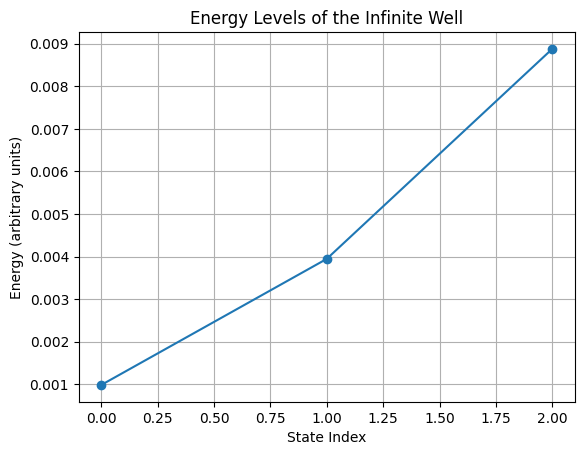

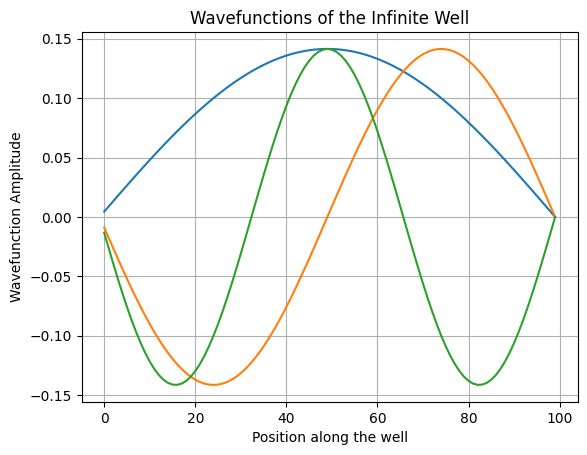

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt



def set_matrix_subdiagonal(matrix, value):
    for i in range(1, len(matrix) - 1):
        matrix[i][i-1] = value
        matrix[i][i+1] = value



class InfiniteWellSolver:
    def __init__(self, N):
        self.N = N
        self.matrix = np.zeros((N, N))
        set_matrix_subdiagonal(self.matrix, 1)
        np.fill_diagonal(self.matrix, -2)
        self.H = - self.matrix

    def solve(self):
        energies, wavefunctions = np.linalg.eigh(self.H)
        return energies, wavefunctions
    
    def plot_results(self, k):
        energies, wavefunctions = self.solve()
        plt.plot(energies[:k], 'o-')
        plt.xlabel('State Index')
        plt.ylabel('Energy (arbitrary units)')
        plt.title('Energy Levels of the Infinite Well')
        plt.grid()
        plt.show()
        plt.plot(wavefunctions[:, :k])
        plt.xlabel('Position along the well')
        plt.ylabel('Wavefunction Amplitude')
        plt.title('Wavefunctions of the Infinite Well')
        plt.grid()
        plt.show()

N = int(input("Enter the number of segments in the infinite well: "))
k = int(input("Enter the number of energy levels to plot: "))
solver = InfiniteWellSolver(N)
solver.plot_results(k)





    

第 58 题：量子隧道效应的伏笔——势垒模拟

题目描述：
我们在势阱的中间放一块“砖头”（势垒）。虽然经典力学里粒子如果能量不够就跳不过去，但在量子力学里，粒子可能会“渗透”过去。

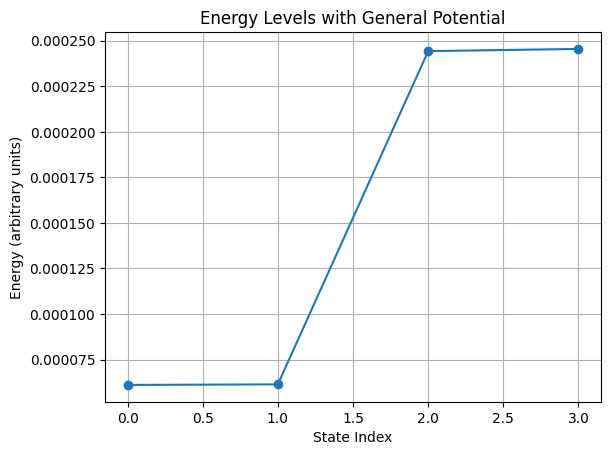

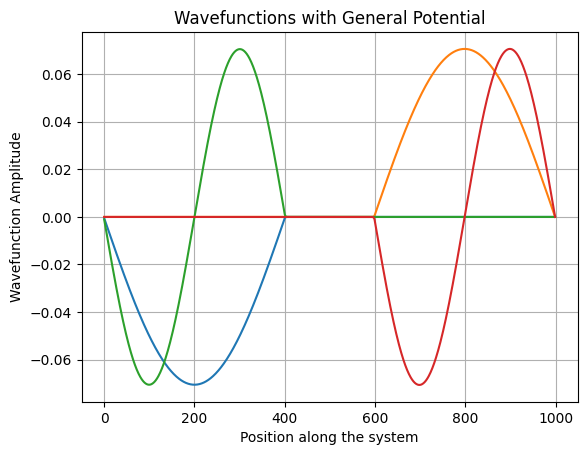

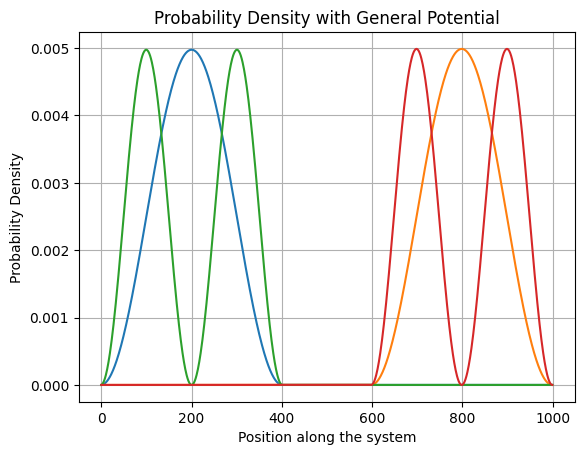

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt



def set_matrix_subdiagonal(matrix, value):
    for i in range(1, len(matrix) - 1):
        matrix[i][i-1] = value
        matrix[i][i+1] = value

class GeneralPotentialSolver:
    def __init__(self, N, V_array):
        self.N = N
        self.matrix = np.zeros((N, N))
        set_matrix_subdiagonal(self.matrix, 1)
        np.fill_diagonal(self.matrix, -2)
        V = np.diag(V_array)
        self.H = -self.matrix + V

    def solve(self):
        energies, wavefunctions = np.linalg.eigh(self.H)
        return energies, wavefunctions
    
    def plot_results(self, k):
        energies, wavefunctions = self.solve()
        probility_density = np.abs(wavefunctions)**2

        plt.plot(energies[:k], 'o-')
        plt.xlabel('State Index')
        plt.ylabel('Energy (arbitrary units)')
        plt.title('Energy Levels with General Potential')
        plt.grid()
        plt.show()
        plt.plot(wavefunctions[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Wavefunction Amplitude')
        plt.title('Wavefunctions with General Potential')
        plt.grid()
        plt.show()
        plt.plot(probility_density[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Probability Density')
        plt.title('Probability Density with General Potential')
        plt.grid()
        plt.show()


N = 1000
V_array = np.zeros(N)
start =max(0,(N -200)//2)
end = min(N,start + 200)
V_array[start:end] = 0.5
k = int(input("Enter the number of energy levels to plot: "))
solver = GeneralPotentialSolver(N, V_array)
solver.plot_results(k)



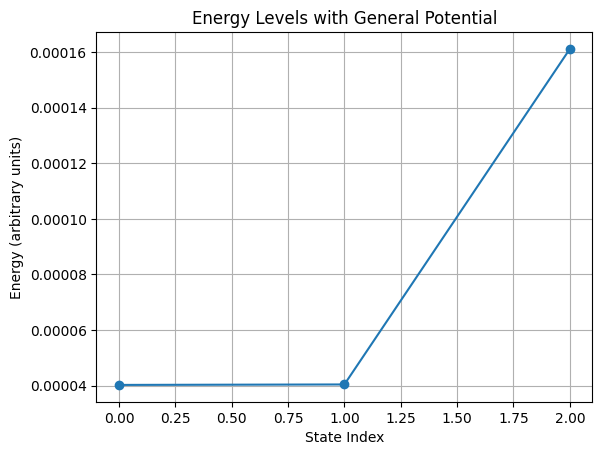

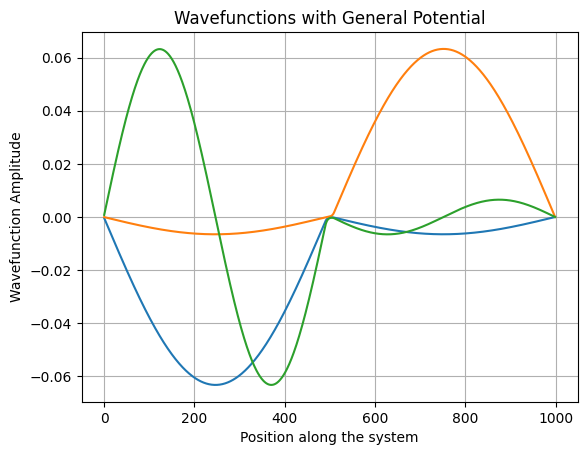

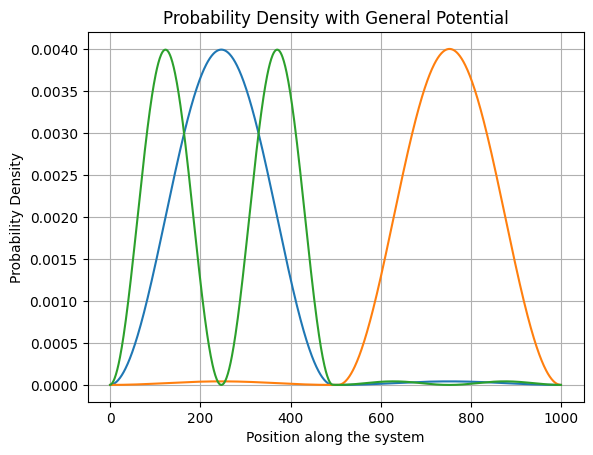

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt



def set_matrix_subdiagonal(matrix, value):
    for i in range(1, len(matrix) - 1):
        matrix[i][i-1] = value
        matrix[i][i+1] = value

class GeneralPotentialSolver:
    def __init__(self, N, V_array):
        self.N = N
        self.matrix = np.zeros((N, N))
        set_matrix_subdiagonal(self.matrix, 1)
        np.fill_diagonal(self.matrix, -2)
        V = np.diag(V_array)
        self.H = -self.matrix + V

    def solve(self):
        energies, wavefunctions = np.linalg.eigh(self.H)
        return energies, wavefunctions
    
    def plot_results(self, k):
        energies, wavefunctions = self.solve()
        probility_density = np.abs(wavefunctions)**2

        plt.plot(energies[:k], 'o-')
        plt.xlabel('State Index')
        plt.ylabel('Energy (arbitrary units)')
        plt.title('Energy Levels with General Potential')
        plt.grid()
        plt.show()
        plt.plot(wavefunctions[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Wavefunction Amplitude')
        plt.title('Wavefunctions with General Potential')
        plt.grid()
        plt.show()
        plt.plot(probility_density[:, :k])
        plt.xlabel('Position along the system')
        plt.ylabel('Probability Density')
        plt.title('Probability Density with General Potential')
        plt.grid()
        plt.show()


N = 1000
V_array = np.zeros(N)
start =max(0,(N -20)//2)
end = min(N,start + 20)
V_array[start:end] = 0.05
k = int(input("Enter the number of energy levels to plot: "))
solver = GeneralPotentialSolver(N, V_array)
solver.plot_results(k)

